In [ ]:
#KAVIBHARATHI K
#212224220045

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [ ]:
import numpy as np
from torchsummary import summary

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torchsummary import summary

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [4]:
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.12MB/s]
Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

100%|██████████| 1.65M/1.65M [00:00<00:00, 3.87MB/s]
Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw


In [5]:
train_loader = DataLoader(dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [6]:
# Add noise to images
def add_noise(inputs, noise_factor=0.5):
    noisy = inputs + noise_factor * torch.randn_like(inputs)
    return torch.clamp(noisy, 0., 1.)

In [7]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3,
                               stride=2, padding=1, output_padding=1),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=3,
                               stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [8]:
model = DenoisingAutoencoder().to(device)

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 14, 14]             160
              ReLU-2           [-1, 16, 14, 14]               0
            Conv2d-3             [-1, 32, 7, 7]           4,640
              ReLU-4             [-1, 32, 7, 7]               0
   ConvTranspose2d-5           [-1, 16, 14, 14]           4,624
              ReLU-6           [-1, 16, 14, 14]               0
   ConvTranspose2d-7            [-1, 1, 28, 28]             145
           Sigmoid-8            [-1, 1, 28, 28]               0
Total params: 9,569
Trainable params: 9,569
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.13
Params size (MB): 0.04
Estimated Total Size (MB): 0.17
----------------------------------------------------------------


In [10]:
def train(model, loader, criterion, optimizer, epochs=5):

    model.train()

    for epoch in range(epochs):

        running_loss = 0.0

        for images, _ in loader:

            images = images.to(device)

            # Add noise
            noisy_images = add_noise(images).to(device)

            # Forward pass
            outputs = model(noisy_images)

            loss = criterion(outputs, images)

            # Backpropagation
            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(loader):.4f}")

In [11]:
def visualize_denoising(model, loader, num_images=10):

    model.eval()

    with torch.no_grad():

        for images, _ in loader:

            images = images.to(device)

            noisy_images = add_noise(images).to(device)

            outputs = model(noisy_images)

            break

    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    outputs = outputs.cpu().numpy()

    print("Name: Kavibharathi K")
    print("Register Number: 212224220045")

    plt.figure(figsize=(18, 6))

    for i in range(num_images):

        # Original
        ax = plt.subplot(3, num_images, i + 1)

        plt.imshow(images[i].squeeze(), cmap='gray')

        ax.set_title("Original")

        plt.axis("off")

        # Noisy
        ax = plt.subplot(3, num_images, i + 1 + num_images)

        plt.imshow(noisy_images[i].squeeze(), cmap='gray')

        ax.set_title("Noisy")

        plt.axis("off")

        # Denoised
        ax = plt.subplot(3, num_images, i + 1 + 2 * num_images)

        plt.imshow(outputs[i].squeeze(), cmap='gray')

        ax.set_title("Denoised")

        plt.axis("off")

    plt.tight_layout()

    plt.show()

In [12]:
train(model, train_loader, criterion, optimizer, epochs=5)

Epoch [1/5], Loss: 0.1524
Epoch [2/5], Loss: 0.0321
Epoch [3/5], Loss: 0.0130
Epoch [4/5], Loss: 0.0107
Epoch [5/5], Loss: 0.0096


Name: Kavibharathi K
Register Number: 212224220045


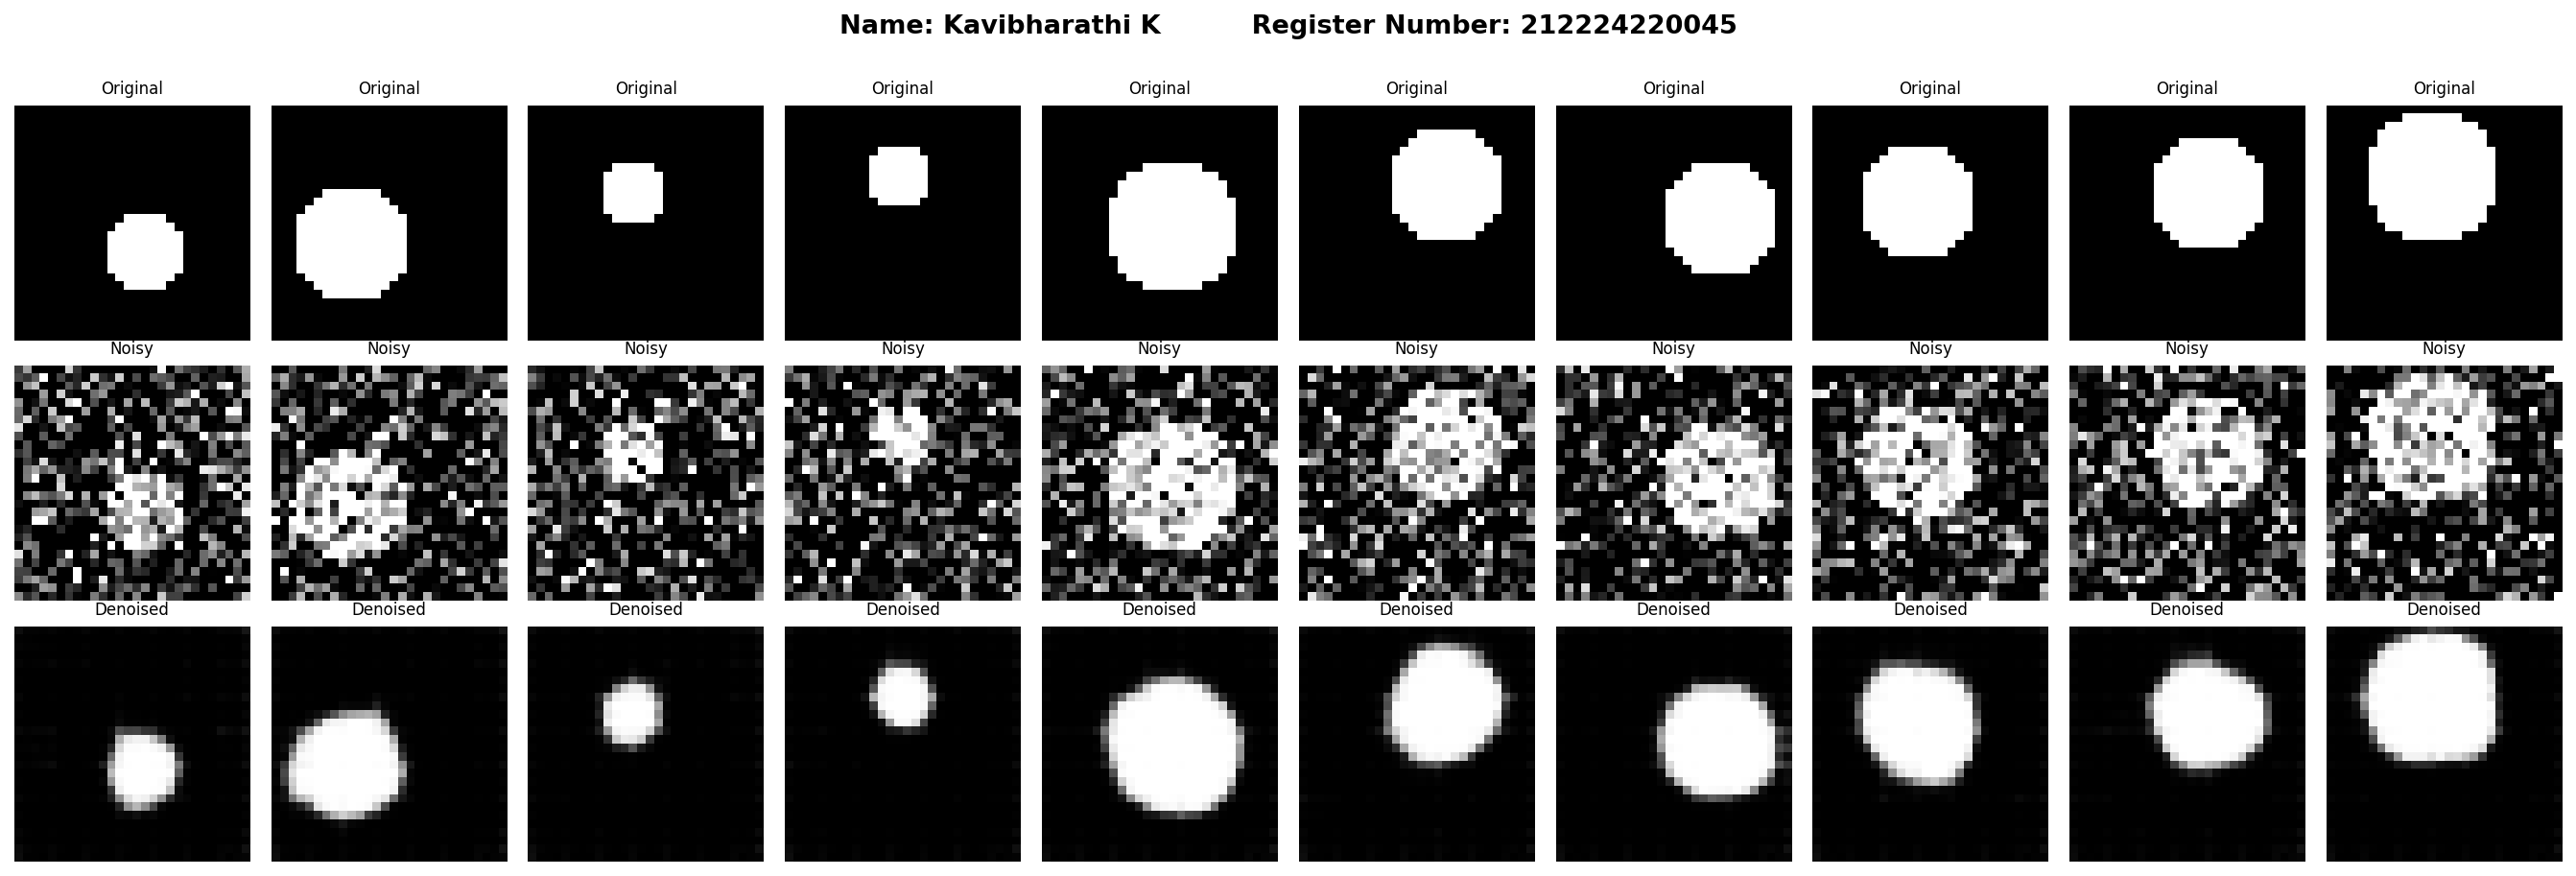

In [13]:
visualize_denoising(model, test_loader)